In [ ]:
!pip install transformers accelerate peft bitsandbytes torch --upgrade

from transformers import Blip2Processor, Blip2ForConditionalGeneration, LlamaForCausalLM, LlamaTokenizer
import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 42.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.1
    Uninstalling transformers-4.56.1:
      Successfully uninstalled transformers-4.56.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model
import torch

# Load processor with fast tokenizer
processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
# processor = Blip2Processor.from_pretrained(.SYSSY, use_fast=True)

# Load model in FP32 to avoid dtype issues
print("Loading model in FP32...")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl",
    torch_dtype=torch.float32,  # Use FP32 instead of FP16
    device_map="auto",
)

# Ensure all model components are in FP32
model = model.float()

# Freeze vision encoder and Q-Former explicitly
print("Freezing vision encoder and Q-Former...")
frozen_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    if "vision_model" in name or "qformer" in name:
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        trainable_params += param.numel()

print(f"Frozen parameters: {frozen_params:,}")
print(f"Trainable parameters before LoRA: {trainable_params:,}")

# Apply LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q", "k", "v", "o", "wi", "wo"],  # T5 modules
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)
model = get_peft_model(model, lora_config)

# Print trainable parameters after LoRA
lora_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after LoRA: {lora_params:,}")
print(f"Percentage of trainable params: {100 * lora_params / (frozen_params + trainable_params):.2f}%")

# Ensure model is on GPU and in FP32
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model = model.float()  # Ensure FP32

print(f"Model loaded on {device} in FP32 mode")

# Verify model dtypes
print("\nModel component dtypes:")
for name, module in model.named_modules():
    if hasattr(module, 'weight') and module.weight is not None:
        print(f"{name}: {module.weight.dtype}")
        break

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/5.81G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Freezing vision encoder and Q-Former...
Frozen parameters: 1,091,089,920
Trainable parameters before LoRA: 2,851,356,672
Trainable parameters after LoRA: 12,189,696
Percentage of trainable params: 0.31%
Model loaded on cuda in FP32 mode

Model component dtypes:
base_model.model.vision_model.embeddings.patch_embedding: torch.float32


In [ ]:
import os
import pandas as pd
from collections import defaultdict
from glob import glob

# Paths
CSV_PATH = "/content/drive/My Drive/master_thesis_project/met_metadata_0509.csv"
IMG_DIR  = "/content/drive/My Drive/master_thesis_project/met_images"

# Build artefact_id -> [image_paths]
image_map = defaultdict(list)
for path in glob(os.path.join(IMG_DIR, "*.*")):
    if path.lower().endswith((".jpg", ".jpeg", ".png")):
        fname = os.path.basename(path)
        artefact_id = fname.split("_")[0]  # part before first "_"
        image_map[str(artefact_id)].append(path)

# Sort so that primary is always first, then additional0, additional1, ...
def sort_key(p):
    fname = os.path.basename(p)
    if "_primary" in fname:
        return (0, 0)  # always first
    elif "_additional" in fname:
        try:
            num = int(fname.split("_additional")[1].split(".")[0])
        except:
            num = 999
        return (1, num)
    else:
        return (2, fname)  # fallback

for k in image_map:
    image_map[k] = sorted(image_map[k], key=sort_key)

# Load metadata
df = pd.read_csv(CSV_PATH)

# Normalize IDs to string
df["ID"] = df["ID"].astype(str)

# Keep only rows with available images
df = df[df["ID"].isin(image_map.keys())].reset_index(drop=True)

print(f"Total artifacts with images: {len(df)}")

Total artifacts with images: 5727


In [ ]:
df.head()

,ID,Inventory Number,Title,Medium,Date,Standardized Date,Dimension,Period,Culture,Category,Description,Link Resource,Object Wikidata URL,Tags,Tags AAT URL,Bibliography
0,239585,74.51.3631,Pendant in the form of a vase,Gold,5th–4th century BCE,499-300 BCE,Other: 9/16 in. (1.4 cm),Classical,Greek,Gold and Silver,Gold pendant in the form of a vase.,http://www.metmuseum.org/art/collection/search...,https://www.wikidata.org/wiki/Q116305682,NaN,NaN,"Myres, John L. 1914. Handbook of the Cesnola C..."
1,239586,74.51.1,Glass bead,Glass,ca. 330–70 BCE,330-70 BCE,L.: 1 in. (2.4 cm)\r\nDiam.: 3/8 in. (1.0 cm),Hellenistic,Greek,Glass,"Translucent deep purple, appearing black; trai...",http://www.metmuseum.org/art/collection/search...,NaN,NaN,NaN,"Cesnola, Luigi Palma di. 1903. A Descriptive A..."
2,239588,74.51.3,Glass eye bead,Glass,6th–4th century BCE,599-300 BCE,L.: 3/8 in. (1 cm)\r\nDiam.: 15/16 in. (0.9 cm),Archaic or Classical,"Phoenician, Cypriot",Glass,Stratified double eye bead; two sets of four e...,http://www.metmuseum.org/art/collection/search...,NaN,NaN,NaN,"Cesnola, Luigi Palma di. 1903. A Descriptive A..."
3,239593,74.51.8,Glass bead,Glass,ca. 330–70 BCE,330-70 BCE,L. 7/8 in. (2.2 cm)\r\ndiameter 7/16 in. (1.1...,Hellenistic,Greek,Glass,"Uncertain color, probably translucent deep pur...",http://www.metmuseum.org/art/collection/search...,NaN,NaN,NaN,"Myres, John L. 1914. Handbook of the Cesnola C..."
4,239596,74.51.11,Glass bead,Glass,ca. 750–300 BCE,750-300 BCE,L.: 15/16in. (2.5 cm)\r\nDiam.: 3/8in. (1 cm),Archaic or Classical,Cypriot,Glass,"Uncertain color, appearing black; trail in opa...",http://www.metmuseum.org/art/collection/search...,NaN,NaN,NaN,"Myres, John L. 1914. Handbook of the Cesnola C..."


In [ ]:
row_idx = 67
artifact_id = df.loc[row_idx, "ID"]
print("Example mapping:", artifact_id, "->", image_map[artifact_id])

Example mapping: 240026 -> ['/content/drive/My Drive/master_thesis_project/met_images/240026_primary.jpg']


In [ ]:
import re

def clean_material(val: str) -> str:
    if not isinstance(val, str):
        return "Unknown"
    val = val.strip().lower()
    # unify common variants
    replacements = {
        "gold": "Gold",
        "gilded silver": "Silver (gilded)",
        "terracotta appliqué": "Terracotta",
        "terracotta fabric": "Terracotta",
        "marble and limestone": "Marble",
        "white marble": "Marble",
        "beige marble": "Marble",
        "limestone": "Limestone",
        "hard limestone": "Limestone",
        "chalk limestone": "Limestone",
        "liimestone": "Limestone",
        "calcite (alabaster)": "Alabaster",
        "gypsum (alabaster)": "Alabaster",
        "dark alabaster": "Alabaster",
        "veined alabaster": "Alabaster",
    }
    for k, v in replacements.items():
        if k in val:
            return v
    return val.title()

def clean_culture(val: str) -> str:
    if not isinstance(val, str):
        return "Unknown"
    val = val.strip()
    val = re.sub(r"\?|\(|\)|Probably|Possibly|Late|Early|:", "", val, flags=re.I)  # remove uncertainty markers
    val = val.replace("or", "/")  # normalize "or" to slash
    val = re.sub(r"\s+", " ", val).strip()
    return val.title() if val else "Unknown"

def clean_category(val: str) -> list:
    if not isinstance(val, str):
        return ["Unknown"]
    parts = [p.strip() for p in val.split("|")]
    return [p.title() for p in parts if p]

In [ ]:
df["Material_clean"] = df["Medium"].apply(clean_material)
df["Culture_clean"]  = df["Culture"].apply(clean_culture)
df["Category_clean"] = df["Category"].apply(clean_category)

In [ ]:
df[["Medium", "Material_clean", "Culture", "Culture_clean", "Category", "Category_clean"]].head(10)

,Medium,Material_clean,Culture,Culture_clean,Category,Category_clean
0,Gold,Gold,Greek,Greek,Gold and Silver,[Gold And Silver]
1,Glass,Glass,Greek,Greek,Glass,[Glass]
2,Glass,Glass,"Phoenician, Cypriot","Phoenician, Cypriot",Glass,[Glass]
3,Glass,Glass,Greek,Greek,Glass,[Glass]
4,Glass,Glass,Cypriot,Cypriot,Glass,[Glass]
5,Glass,Glass,Phoenician,Phoenician,Glass,[Glass]
6,Glass,Glass,Phoenician,Phoenician,Glass,[Glass]
7,Glass,Glass,Probably Phoenician,Phoenician,Glass,[Glass]
8,Glass,Glass,Phoenician,Phoenician,Glass,[Glass]
9,Glass,Glass,"Greek, Eastern Mediterranean","Greek, Eastern Mediterranean",Glass,[Glass]


In [ ]:
import matplotlib.pyplot as plt

def analyze_class_distribution(df, field="Culture", top_n=20):
    """
    Analyze and plot class distribution for a given field.
    Uses cleaned version if available (e.g., 'Culture_clean').
    """
    # pick cleaned column if it exists
    clean_field = f"{field}_clean"
    col = clean_field if clean_field in df.columns else field

    series = df[col]

    # flatten if values are lists (like Category_clean)
    if series.apply(lambda x: isinstance(x, list)).any():
        series = series.explode()

    counts = series.value_counts()

    print(f"\nTop {top_n} classes for {col}:")
    print(counts.head(top_n))

    # Plot
    counts.head(top_n).plot(kind="bar", figsize=(10, 5))
    plt.title(f"Top {top_n} {col} classes")
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.show()

    return counts


Top 15 classes for Culture_clean:
Culture_clean
Cypriot                            1354
Greek, Attic                        985
Greek                               759
Etruscan                            698
Greek, Eastern Mediterranean        182
Greek, South Italian, Apulian       136
Italic                              126
Greek, Laconian                     118
Greek, C/Inthian                     96
Greek, South Italian, Tarentine      78
Greek, South Italian, Campanian      69
Greek, Boeotian                      67
East Greek                           65
Roman                                64
Greek, Cypriot                       52
Name: count, dtype: int64


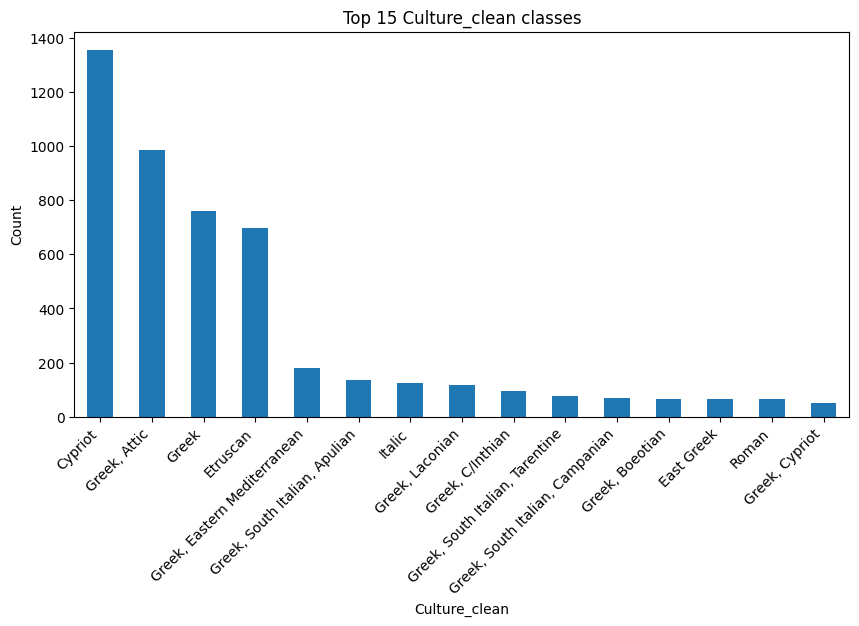


Top 15 classes for Material_clean:
Material_clean
Terracotta          2898
Bronze               764
Gold                 563
Limestone            429
Glass                333
Lead                  95
Silver                88
Marble                71
Alabaster             44
Amber                 43
Carnelian             42
Clay, Glazed          27
Faience               19
Marble, Pentelic      19
Iron                  18
Name: count, dtype: int64


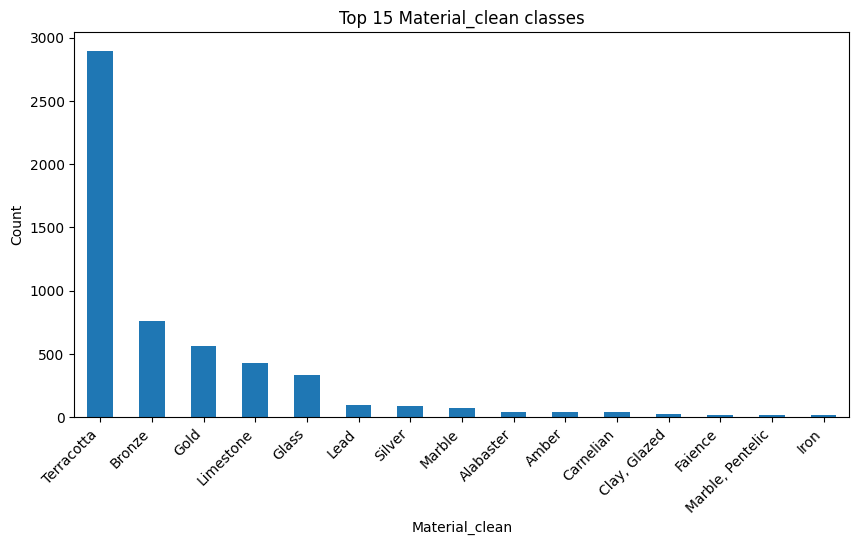


Top 15 classes for Category_clean:
Category_clean
Vases                        2172
Bronzes                       781
Terracottas                   741
Gold And Silver               641
Stone Sculpture               500
Glass                         350
Gems                          221
Miscellaneous-Lead             95
Miscellaneous-Stone Vases      50
Coins                          48
Miscellaneous-Amber            46
Cesnola Inscriptions           39
Miscellaneous-Stone            29
Miscellaneous-Paintings        22
Miscellaneous-Iron             19
Name: count, dtype: int64


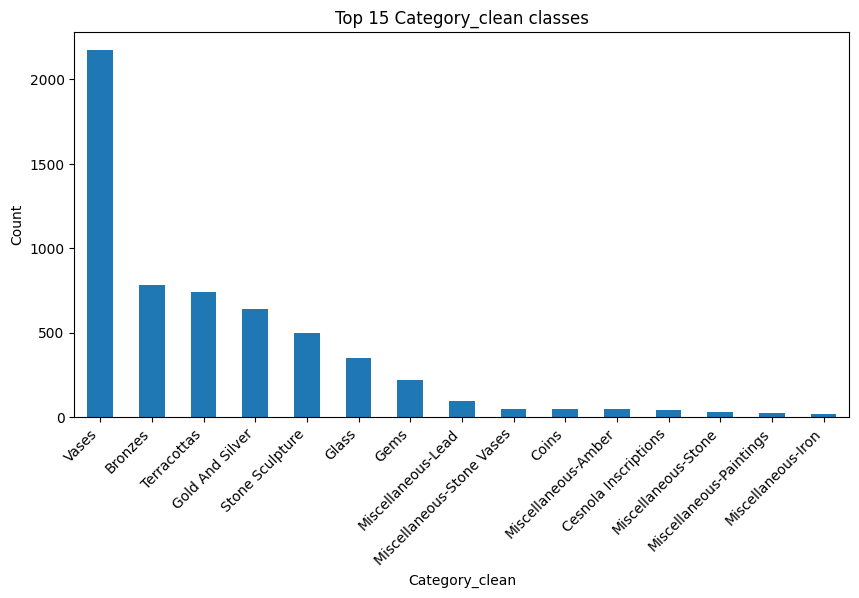

,count
Category_clean,
Vases,2172
Bronzes,781
Terracottas,741
Gold And Silver,641
Stone Sculpture,500
Glass,350
Gems,221
Miscellaneous-Lead,95
Miscellaneous-Stone Vases,50


In [ ]:
# Now analyze with auto-clean fallback
analyze_class_distribution(df, "Culture", top_n=15)
analyze_class_distribution(df, "Material", top_n=15)
analyze_class_distribution(df, "Category", top_n=15)

In [ ]:
def extract_per_category_weights(df):
    """Calculate class weights for each category separately using cleaned values"""
    from collections import Counter
    import numpy as np

    # Apply cleaning functions to get clean values
    material_values = [clean_material(val) for val in df['Medium'].fillna('Unknown')]
    culture_values = [clean_culture(val) for val in df['Culture'].fillna('Unknown')]

    # For category, take the first element from the list returned by clean_category
    category_values = []
    for val in df['Category'].fillna('Unknown'):
        cleaned = clean_category(val)
        category_values.append(cleaned[0] if cleaned else "Unknown")  # Take first element as string

    # Count occurrences
    material_counts = Counter(material_values)
    culture_counts = Counter(culture_values)
    category_counts = Counter(category_values)

    # Calculate weights for each category (inverse frequency)
    def calculate_weights(counts):
        total = sum(counts.values())
        return {cls: total / (len(counts) * count) for cls, count in counts.items()}

    material_weights = calculate_weights(material_counts)
    culture_weights = calculate_weights(culture_counts)
    category_weights = calculate_weights(category_counts)

    print("Material distribution:")
    for mat, count in material_counts.most_common():
        print(f"  {mat}: {count} samples (weight: {material_weights[mat]:.2f})")

    print("\nCulture distribution:")
    for cul, count in culture_counts.most_common():
        print(f"  {cul}: {count} samples (weight: {culture_weights[cul]:.2f})")

    print("\nCategory distribution:")
    for cat, count in category_counts.most_common():
        print(f"  {cat}: {count} samples (weight: {category_weights[cat]:.2f})")

    return material_weights, culture_weights, category_weights

In [ ]:
import random
from torch.utils.data import Dataset
import pandas as pd

class ArtefactDataset(Dataset):
    def __init__(self, df, image_map, mix_prob=0.5):
        self.df = df
        self.image_map = image_map
        self.mix_prob = mix_prob

    def __len__(self):
        return len(self.df)

    def _make_classification_io(self, row):
        # English Q-A format
        prompt = "Question: What are the material, culture, and category of this object? Answer:"
        target = f"Material: {row['Medium']}, Culture: {row['Culture']}, Category: {row['Category']}"
        return prompt, target

    def _make_description_io(self, row):
        desc = row.get("Description")
        if pd.isna(desc) or not isinstance(desc, str) or len(desc.strip()) == 0:
            return self._make_classification_io(row)
        prompt = "Question: Describe this object in detail. Answer:"
        return prompt, desc.strip()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        artefact_id = str(row["ID"])

        # choose task
        if random.random() < self.mix_prob:
            prompt, target = self._make_classification_io(row)
        else:
            prompt, target = self._make_description_io(row)

        return {
            "id": artefact_id,
            "image_paths": self.image_map[artefact_id],
            "prompt": prompt,
            "target": target,
        }

In [ ]:
from datasets import Dataset as HFDataset, DatasetDict

# wrap df into Hugging Face Dataset
hf_all = HFDataset.from_pandas(df, preserve_index=False)

# First split → 80% train, 20% temp
splits = hf_all.train_test_split(test_size=0.2, seed=3407)

# Second split → temp → 50% val, 50% test
val_test = splits["test"].train_test_split(test_size=0.5, seed=3407)

# Final splits
hf_splits = DatasetDict({
    "train": splits["train"],
    "val": val_test["train"],
    "test": val_test["test"],
})

# extract IDs for each split
ids_train = set(hf_splits["train"]["ID"])
ids_val   = set(hf_splits["val"]["ID"])
ids_test  = set(hf_splits["test"]["ID"])

# filter pandas DataFrames
df_train = df[df["ID"].isin(ids_train)].reset_index(drop=True)
df_val   = df[df["ID"].isin(ids_val)].reset_index(drop=True)
df_test  = df[df["ID"].isin(ids_test)].reset_index(drop=True)

# wrap into PyTorch Dataset
train_ds = ArtefactDataset(df_train, image_map, mix_prob=0.5)
val_ds   = ArtefactDataset(df_val,   image_map, mix_prob=0.5)
test_ds  = ArtefactDataset(df_test,  image_map, mix_prob=0.5)

In [ ]:
# Calculate weights
material_weights, culture_weights, category_weights = extract_per_category_weights(df_train)

Material distribution:
  Terracotta: 2307 samples (weight: 0.02)
  Bronze: 613 samples (weight: 0.06)
  Gold: 440 samples (weight: 0.09)
  Limestone: 357 samples (weight: 0.11)
  Glass: 276 samples (weight: 0.14)
  Lead: 81 samples (weight: 0.48)
  Silver: 66 samples (weight: 0.59)
  Marble: 55 samples (weight: 0.71)
  Amber: 38 samples (weight: 1.02)
  Alabaster: 33 samples (weight: 1.18)
  Carnelian: 32 samples (weight: 1.21)
  Clay, Glazed: 22 samples (weight: 1.76)
  Iron: 16 samples (weight: 2.43)
  Fresco: 16 samples (weight: 2.43)
  Marble, Pentelic: 15 samples (weight: 2.59)
  Agate: 12 samples (weight: 3.24)
  Faience: 12 samples (weight: 3.24)
  Chalcedony: 11 samples (weight: 3.53)
  Agate, Banded: 8 samples (weight: 4.85)
  Electrum: 7 samples (weight: 5.55)
  Sard: 7 samples (weight: 5.55)
  Marble, Parian: 6 samples (weight: 6.47)
  Ivory: 5 samples (weight: 7.76)
  Silver, Agate: 4 samples (weight: 9.71)
  Silver, Sard: 4 samples (weight: 9.71)
  Jasper, Red: 4 samples (

In [ ]:
from PIL import Image
import torch

def collate_fn(batch, processor, image_size=(224, 224)):
    """
    Collate function for BLIP-2 with Flan-T5 - Fixed dtype consistency
    images are stacked together into tensors, but inside one batch, only when each sample has the same number of images, they can be stacked, so find the max number of images per batch, and then pad each sample with dummy gray images. For the images, there is an image_mask (1 for real images and 0 for padded images).
    """
    texts = [s["prompt"] for s in batch]
    targets = [s["target"] for s in batch]
    image_lists = [s["image_paths"] for s in batch]

    bs = len(batch)
    max_images = max(len(imgs) for imgs in image_lists)

    padded_images = []
    image_mask = []

    for imgs in image_lists:
        # Sort images: primary first, then additional numerically
        # All images are treated as a sequence of embeddings. The embeddings from all images are fed into the language model. BLIP-2’s Flan-T5 doesn’t assume a special ordering of images. It uses attention over all image embeddings to condition the text generation.
        # If _primary is visually distinct and more informative, putting it first can help the model learn a more consistent pattern. If all images are roughly equal in importance, order doesn’t matter.
        imgs = sorted(imgs, key=lambda x: (0 if "_primary" in x else int(x.split("_")[-1].split(".")[0])))
        n = len(imgs)
        mask = [1] * n + [0] * (max_images - n)
        image_mask.append(mask)

        # Load images and pad with dummy gray images
        loaded = [Image.open(p).convert("RGB") for p in imgs]
        if n < max_images:
            loaded += [Image.new("RGB", image_size, "gray")] * (max_images - n)
        padded_images.extend(loaded)

    # Process all images at once - Keep in FP32 for consistency
    pixel_values = processor(images=padded_images, return_tensors="pt").pixel_values
    pixel_values = pixel_values.reshape(bs, max_images, *pixel_values.shape[1:]) # Remove .half() - keep in FP32

    # Process texts and targets in one go using text_target
    tokenized = processor(
        text=texts,
        text_target=targets,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )

    input_ids = tokenized["input_ids"]
    attention_mask = tokenized["attention_mask"]
    labels = tokenized["labels"].long()  # ensure correct type

    return {
        "pixel_values": pixel_values,           # (bs, max_images, C, H, W) - FP32
        "image_mask": torch.tensor(image_mask), # (bs, max_images)
        "input_ids": input_ids,                 # (bs, seq_len)
        "attention_mask": attention_mask,       # (bs, seq_len)
        "labels": labels,                       # (bs, seq_len) long/int64
    }

In [ ]:
# DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds, batch_size=16, shuffle=True,
    collate_fn=lambda batch: collate_fn(batch, processor, image_size=(224, 224)),
    num_workers=2
)

val_loader = DataLoader(
    val_ds, batch_size=16, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, processor, image_size=(224, 224)),
    num_workers=2
)

test_loader = DataLoader(
    test_ds, batch_size=16, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, processor, image_size=(224, 224)),
    num_workers=2
)

# Verify the split sizes
print(f"Train size: {len(train_ds)} samples")
print(f"Validation size: {len(val_ds)} samples")
print(f"Test size: {len(test_ds)} samples")
print(f"Total: {len(train_ds) + len(val_ds) + len(test_ds)} samples")
print(f"Split ratio: {len(train_ds)/len(df):.1%} : {len(val_ds)/len(df):.1%} : {len(test_ds)/len(df):.1%}")

Train size: 4581 samples
Validation size: 573 samples
Test size: 573 samples
Total: 5727 samples
Split ratio: 80.0% : 10.0% : 10.0%


In [ ]:
from tqdm import tqdm
import torch

def process_multiple_images(model, pixel_values, image_mask, input_ids, attention_mask, labels):
    """
    Prepare multiple images per sample, extract vision features, fuse them with text embeddings, and return combined tensors for the language model.
    """
    bs, max_images, C, H, W = pixel_values.shape # (batch size, number of images per sample(padded to the max_images), and image shape)

    # Ensure input tensors are contiguous
    pixel_values = pixel_values.contiguous()
    image_mask = image_mask.contiguous()

    # Process all images through vision encoder
    pixel_values_flat = pixel_values.view(bs * max_images, C, H, W).contiguous() # Flatten batch × images

    with torch.no_grad():
        vision_outputs = model.vision_model(pixel_values_flat, return_dict=True)
        image_embeds = vision_outputs.last_hidden_state.contiguous()

    # Reshape back to (bs, max_images, seq_len, hidden_dim), this groups embeddings per sample and per image again, becasue after flattening, PyTorch doesn’t know which embeddings belong to which sample, reshaping stores this structure
    image_embeds = image_embeds.view(bs, max_images, -1, image_embeds.size(-1)).contiguous()

    # Apply mask to zero out padding images
    mask_exp = image_mask.unsqueeze(-1).unsqueeze(-1).float().contiguous() # image_mask originally has shape (bs, max_images) → 1 for real images, 0 for padding. # .unsqueeze(-1) adds a new dimension at the end. Doing it twice turns it into (bs, max_images, 1, 1), This allows it to broadcast properly when multiplied with image_embeds, which has shape: (bs, max_images, seq_len, hidden_dim)
    image_embeds = (image_embeds * mask_exp).contiguous()

    # Average features across valid images
    # Sums embeddings across all images per sample → (bs, seq_len, hidden_dim). Divides by the number of valid images → average pooling. clamp(min=1) avoids division by zero if all are padded.
    num_valid_images = image_mask.sum(dim=1, keepdim=True).unsqueeze(-1).clamp(min=1).float().contiguous()
    pooled_embeds = (image_embeds.sum(dim=1) / num_valid_images).contiguous()

    # Process through Q-Former
    query_tokens = model.query_tokens.expand(bs, -1, -1).contiguous() #Prepare Q-Former queries, BLIP-2 uses learned query tokens to extract compact visual features, expand → repeat the query tokens across the batch

    with torch.no_grad(): # Q-Former forward pass
        qformer_outputs = model.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=pooled_embeds,
            encoder_attention_mask=None,
            return_dict=True,
        )

    # Get language model inputs
    language_model_inputs = model.language_projection(qformer_outputs.last_hidden_state).contiguous() # Map Q-Former outputs into LM space, Projects Q-Former features into the same embedding space as the language model (T5)
    text_embeds = model.language_model.get_input_embeddings()(input_ids).contiguous() # Get text embeddings, Shape: (bs, seq_len, hidden_dim)

    # Combine visual and text features
    combined_embeds = torch.cat([language_model_inputs, text_embeds], dim=1).contiguous()

    # Create attention mask
    visual_attention = torch.ones(language_model_inputs.shape[:2], device=device).contiguous() # These are visual embeddings, not text tokens. Visual tokens always get attention = 1, torch.ones(...) sets all entries to 1, We always want the language model to “pay attention” to all visual tokens.No padding is applied to visual tokens here because the pooling step already ignores padded images via masking.So every visual token is informative, hence attention = 1.
    combined_attention = torch.cat([visual_attention, attention_mask], dim=1).contiguous() # Text tokens get a mask (attention_mask) because some sentences are shorter, so padding tokens must be ignored (0). Visual tokens are never “padding” after pooling — even if a sample had fewer images, the embeddings of missing images were zeroed out and averaged in pooled_embeds. Therefore, no attention masking is needed.

    # Prepare labels (ignore visual tokens)
    num_visual_tokens = language_model_inputs.size(1)
    ignore_labels = torch.full((bs, num_visual_tokens), -100, device=device, dtype=labels.dtype).contiguous() # -100 is ignored by CrossEntropyLoss
    labels_padded = torch.cat([ignore_labels, labels], dim=1).contiguous() # Now the LM sees the full input sequence (visual + text) and the loss is only computed on the text part, not the visual part

    # Ensure sequence lengths match, Aligns labels to be the same length as embeddings, Pads or trims with -100 if mismatched
    seq_len = combined_embeds.size(1)
    if labels_padded.size(1) > seq_len:
        labels_padded = labels_padded[:, :seq_len].contiguous()
    elif labels_padded.size(1) < seq_len:
        padding = torch.full((bs, seq_len - labels_padded.size(1)), -100,
                           device=device, dtype=labels.dtype).contiguous()
        labels_padded = torch.cat([labels_padded, padding], dim=1).contiguous()

    return combined_embeds, combined_attention, labels_padded

In [ ]:
import torch
from tqdm import tqdm
import os
from transformers import get_linear_schedule_with_warmup, Blip2ForConditionalGeneration, Blip2Processor

# CONFIGURATION
EPOCHS = 100
PATIENCE = 7  # Early stopping patience
SAVE_PATH = "/content/drive/My Drive/master_thesis_project/blip2_flan_t5_xl_fine_tuned_MET"
LEARNING_RATE = 3e-5
MAX_GEN_LENGTH = 150

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# OPTIMIZER
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# class weights - FIXED VERSION
def get_category_value(row):
    """Safely extract category value, handling lists"""
    category_val = row["Category_clean"]
    if isinstance(category_val, list):
        return category_val[0] if category_val else "Unknown"
    return category_val

material_weights_tensor = torch.tensor([material_weights[row["Material_clean"]]
                                      for _, row in df_train.iterrows()]).to(device)
culture_weights_tensor = torch.tensor([culture_weights[row["Culture_clean"]]
                                     for _, row in df_train.iterrows()]).to(device)
category_weights_tensor = torch.tensor([category_weights[get_category_value(row)]
                                      for _, row in df_train.iterrows()]).to(device)

# LR SCHEDULER (linear warmup + decay)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# EARLY STOPPING
best_val_loss = float("inf")
epochs_no_improve = 0

# LOSSES
train_losses = []
val_losses = []

# TRAINING LOOP
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    successful_batches = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for batch_idx, batch in pbar:
        try:
            optimizer.zero_grad()

            # Move tensors to device
            pixel_values = batch['pixel_values'].to(device).float().contiguous()
            labels = batch['labels'].to(device).contiguous()
            image_mask = batch['image_mask'].to(device).contiguous()
            input_ids = batch['input_ids'].to(device).contiguous()
            attention_mask = batch['attention_mask'].to(device).contiguous()

            # Process multiple images
            combined_embeds, combined_attention, labels_padded = process_multiple_images(
                model, pixel_values, image_mask, input_ids, attention_mask, labels
            )

            # Forward
            outputs = model.language_model(
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                labels=labels_padded,
                return_dict=True,
            )

            # Get batch indices - FIXED to handle edge cases
            start_idx = batch_idx * train_loader.batch_size
            end_idx = min((batch_idx + 1) * train_loader.batch_size, len(df_train))
            batch_indices = list(range(start_idx, end_idx))

            # Combine weights from all three categories
            combined_weights = (material_weights_tensor[batch_indices] +
                              culture_weights_tensor[batch_indices] +
                              category_weights_tensor[batch_indices]) / 3.0

            loss = (outputs.loss * combined_weights).mean()

            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            running_train_loss += loss.item()
            successful_batches += 1

            avg_loss = running_train_loss / successful_batches
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "avg loss": f"{avg_loss:.4f}",
                "success": f"{successful_batches}/{batch_idx+1}"
            })

        except Exception as e:
            print(f"\nError in training batch {batch_idx}: {e}")
            continue

    # Average train loss for this epoch
    if successful_batches > 0:
        epoch_train_loss = running_train_loss / successful_batches
    else:
        epoch_train_loss = float("inf")

    train_losses.append(epoch_train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    successful_val_batches = 0
    val_predictions, val_labels_all = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            try:
                pixel_values = batch['pixel_values'].to(device).float().contiguous()
                labels = batch['labels'].to(device).contiguous()
                image_mask = batch['image_mask'].to(device).contiguous()
                input_ids = batch['input_ids'].to(device).contiguous()
                attention_mask = batch['attention_mask'].to(device).contiguous()

                combined_embeds, combined_attention, labels_padded = process_multiple_images(
                    model, pixel_values, image_mask, input_ids, attention_mask, labels
                )

                # Compute val loss
                outputs = model.language_model(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    labels=labels_padded,
                    return_dict=True
                )
                val_loss += outputs.loss.item()
                successful_val_batches += 1

                # Generate predictions (optional)
                generated_ids = model.language_model.generate(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    max_length=MAX_GEN_LENGTH,
                    do_sample=True,
                    top_k=50,
                    top_p=0.95,
                    repetition_penalty=1.2,
                    temperature=0.8
                )

                decoded_preds = processor.tokenizer.batch_decode(
                    generated_ids, skip_special_tokens=True
                )

                # Replace -100 with pad_token_id for decoding labels
                labels_for_decode = labels.clone()
                labels_for_decode[labels_for_decode == -100] = processor.tokenizer.pad_token_id
                decoded_labels = processor.tokenizer.batch_decode(
                    labels_for_decode, skip_special_tokens=True
                )

                val_predictions.extend(decoded_preds)
                val_labels_all.extend(decoded_labels)

            except Exception as e:
                print(f"Validation batch error: {e}")
                continue

    if successful_val_batches > 0:
        epoch_val_loss = val_loss / successful_val_batches
    else:
        epoch_val_loss = float("inf")

    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1} finished. Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

    # CHECKPOINT BEST MODEL
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        model.save_pretrained(SAVE_PATH)
        processor.save_pretrained(SAVE_PATH)
        print(f"Saved new best model at epoch {epoch+1} with val_loss={epoch_val_loss:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # EARLY STOPPING
    if epochs_no_improve >= PATIENCE:
        print(f"No improvement for {PATIENCE} epochs. Stopping early.")
        break

Validating: 100%|██████████| 36/36 [02:18<00:00,  3.84s/it]


Epoch 1 finished. Train Loss: 6.7824, Val Loss: 6.6148
Saved new best model at epoch 1 with val_loss=6.6148


Validating: 100%|██████████| 36/36 [02:27<00:00,  4.10s/it]


Epoch 2 finished. Train Loss: 5.9862, Val Loss: 5.2354
Saved new best model at epoch 2 with val_loss=5.2354


Validating: 100%|██████████| 36/36 [02:57<00:00,  4.92s/it]


...

Epoch 17 finished. Train Loss: 1.3426, Val Loss: 1.3567



Validating: 100%|██████████| 36/36 [04:11<00:00,  6.97s/it]


Epoch 18 finished. Train Loss: 1.3474, Val Loss: 1.2569


Validating: 100%|██████████| 36/36 [03:58<00:00,  6.61s/it]

Epoch 19 finished. Train Loss: 1.3051, Val Loss: 1.2534
No improvement for 7 epochs. Stopping early.


In [ ]:
import torch
from tqdm import tqdm
from transformers import Blip2ForConditionalGeneration, Blip2Processor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best fine-tuned model
SAVE_PATH = "/content/drive/My Drive/master_thesis_project/blip2_flan_t5_xl_fine_tuned_MET"
model = Blip2ForConditionalGeneration.from_pretrained(SAVE_PATH).to(device)
processor = Blip2Processor.from_pretrained(SAVE_PATH)
model.eval()

test_loss = 0.0
successful_batches = 0
test_predictions = []
test_labels_all = []

MAX_GEN_LENGTH = 150  # keep same as training

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc="Testing")):
        try:
            # Move tensors to device
            pixel_values = batch['pixel_values'].to(device).float().contiguous()
            labels = batch['labels'].to(device).contiguous()
            image_mask = batch['image_mask'].to(device).contiguous()
            input_ids = batch['input_ids'].to(device).contiguous()
            attention_mask = batch['attention_mask'].to(device).contiguous()

            # Process multiple images
            combined_embeds, combined_attention, labels_padded = process_multiple_images(
                model, pixel_values, image_mask, input_ids, attention_mask, labels
            )

            # Forward pass for loss - USE THE SAME APPROACH AS TRAINING
            outputs = model.language_model(  # Changed from model.get_base_model().language_model
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                labels=labels_padded,
                return_dict=True
            )
            test_loss += outputs.loss.item()
            successful_batches += 1

            # Generate predictions - USE model.generate() directly (not model.language_model.generate)
            generated_ids = model.language_model.generate(
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                max_length=MAX_GEN_LENGTH,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                repetition_penalty=1.2,
                temperature=0.8
            )

            # Decode predictions
            decoded_preds = processor.tokenizer.batch_decode(
                generated_ids, skip_special_tokens=True
            )

            # Decode labels
            labels_for_decode = labels.clone()
            labels_for_decode[labels_for_decode == -100] = processor.tokenizer.pad_token_id
            decoded_labels = processor.tokenizer.batch_decode(
                labels_for_decode, skip_special_tokens=True
            )

            test_predictions.extend(decoded_preds)
            test_labels_all.extend(decoded_labels)

        except Exception as e:
            print(f"Test batch {batch_idx} error: {e}")
            continue

# Average test loss
if successful_batches > 0:
    test_loss /= successful_batches
else:
    test_loss = float("inf")

print(f"Test Loss: {test_loss:.4f}")
print(f"Number of predictions: {len(test_predictions)}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Testing: 100%|██████████| 36/36 [03:11<00:00,  5.33s/it]

Test Loss: 1.4296
Number of predictions: 573


Learning curves saved to: /content/drive/My Drive/master_thesis_project/blip2_flan_t5_xl_fine_tuned_MET/learning_curves.png


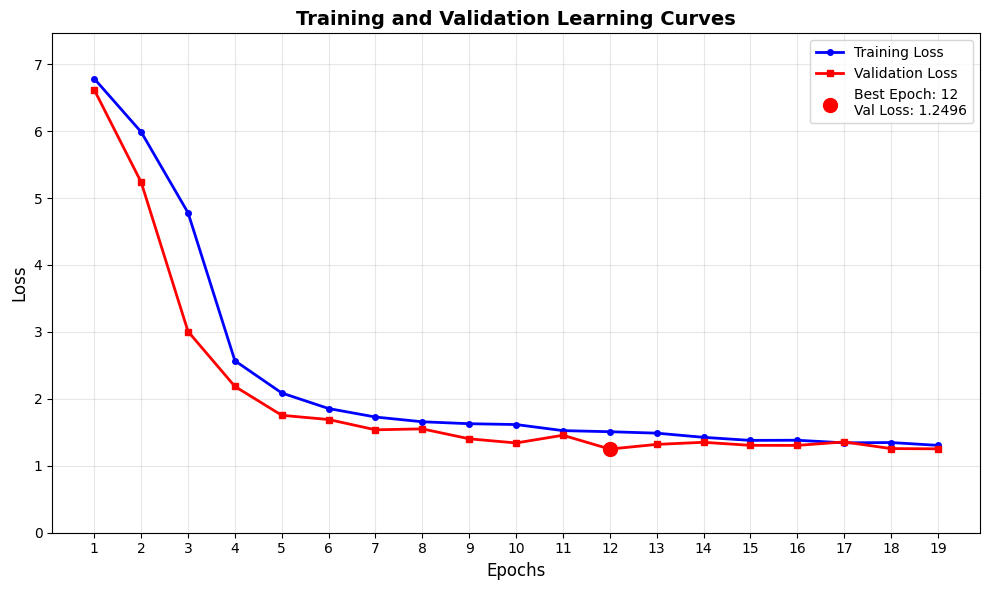


Training Summary:
Best epoch: 12
Best validation loss: 1.2496
Final training loss: 1.3051
Final validation loss: 1.2534


In [ ]:
import numpy as np

def plot_learning_curves(train_losses, val_losses, save_path=None):
    """
    Plot training and validation learning curves with integer epochs
    """
    plt.figure(figsize=(10, 6))

    epochs = range(1, len(train_losses) + 1)

    # Plot losses
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)

    # Find best validation loss point
    best_epoch_idx = np.argmin(val_losses)
    best_epoch = epochs[best_epoch_idx]
    best_val_loss = val_losses[best_epoch_idx]

    # Mark the best epoch
    plt.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5,
                label=f'Best Epoch: {best_epoch}\nVal Loss: {best_val_loss:.4f}')

    plt.title('Training and Validation Learning Curves', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Set x-axis to integer ticks
    plt.xticks(epochs)

    # Set y-axis to start from 0 for better visualization
    max_loss = max(max(train_losses), max(val_losses))
    plt.ylim(0, max_loss * 1.1)

    # Add some styling
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Learning curves saved to: {save_path}")

    plt.show()

    return best_epoch, best_val_loss

# Plot the learning curves after training
if train_losses and val_losses:
    best_epoch, best_val_loss = plot_learning_curves(
        train_losses,
        val_losses,
        save_path=os.path.join(SAVE_PATH, "learning_curves.png")
    )

    print(f"\nTraining Summary:")
    print(f"Best epoch: {best_epoch}")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Final training loss: {train_losses[-1]:.4f}")
    print(f"Final validation loss: {val_losses[-1]:.4f}")

In [ ]:
!pip install rouge-score
!pip install bert-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=8fc6345f066ac0e603fa8cf1e5c561e63625e412019b7ece50c59c9244a0585a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import matplotlib.pyplot as plt
from collections import Counter

def extract_fields(text):
    """Helper: extract fields from classification format with proper parsing"""
    fields = {}
    if not isinstance(text, str):
        return fields

    # Improved parsing that handles the actual format
    for part in text.split(","):
        part = part.strip()
        if ":" in part:
            key_val = part.split(":", 1)
            if len(key_val) == 2:
                key = key_val[0].strip()
                val = key_val[1].strip()

                # Handle different field name variations
                if key in ["Material", "Material_clean"]:
                    fields["Material_clean"] = val
                elif key in ["Culture", "Culture_clean"]:
                    fields["Culture_clean"] = val
                elif key in ["Category", "Category_clean"]:
                    fields["Category_clean"] = val

    return fields

def calculate_classification_metrics(predictions, labels, fields=["Material_clean", "Culture_clean", "Category_clean"]):
    """Calculate classification metrics for each field"""
    results = {}

    for field in fields:
        y_true, y_pred = [], []

        for pred_text, label_text in zip(predictions, labels):
            if not isinstance(pred_text, str) or not isinstance(label_text, str):
                continue

            pred_fields = extract_fields(pred_text)
            label_fields = extract_fields(label_text)

            true_val = label_fields.get(field, "UNKNOWN")
            pred_val = pred_fields.get(field, "UNKNOWN")

            # For culture field, handle the case where ground truth has multiple cultures
            if field == "Culture_clean" and true_val != "UNKNOWN" and pred_val != "UNKNOWN":
                # Split ground truth cultures by commas if it contains multiple
                true_cultures = [c.strip() for c in true_val.split(",")] if "," in true_val else [true_val]
                pred_cultures = [c.strip() for c in pred_val.split(",")] if "," in pred_val else [pred_val]

                # Check if any predicted culture matches any ground truth culture
                match_found = any(pred_c in true_cultures for pred_c in pred_cultures)
                y_true.append("MATCH" if match_found else "NO_MATCH")
                y_pred.append("MATCH")  # We consider it a correct prediction if match found
            else:
                # For other fields, use exact match
                y_true.append(true_val)
                y_pred.append(pred_val)

        if len(y_true) == 0:
            continue

        # Calculate metrics
        acc = accuracy_score(y_true, y_pred)
        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )

        results[field] = {
            "accuracy": acc,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "f1_weighted": f1_weighted,
            "total_samples": len(y_true)
        }

    return results

def calculate_generation_metrics(predictions, labels):
    """Calculate generation metrics for descriptions"""
    if len(predictions) == 0:
        return {}

    # Filter out empty strings and ensure all are strings
    predictions_clean = [str(p) for p in predictions if p and str(p).strip()]
    labels_clean = [str(l) for l in labels if l and str(l).strip()]

    if len(predictions_clean) == 0:
        return {}

    # BLEU Score
    smoothie = SmoothingFunction().method4
    references = [[label.split()] for label in labels_clean]
    candidates = [pred.split() for pred in predictions_clean]

    try:
        bleu_score = corpus_bleu(references, candidates, smoothing_function=smoothie)
    except:
        bleu_score = 0.0

    # ROUGE Scores
    rouge_scorer_obj = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

    for ref, pred in zip(labels_clean, predictions_clean):
        scores = rouge_scorer_obj.score(ref, pred)
        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougeL_scores.append(scores["rougeL"].fmeasure)

    # BERTScore
    try:
        P, R, F1 = bert_score(predictions_clean, labels_clean, lang="en", verbose=False)
        bert_f1 = F1.mean().item()
        bert_precision = P.mean().item()
        bert_recall = R.mean().item()
    except:
        bert_f1 = 0.0
        bert_precision = 0.0
        bert_recall = 0.0

    return {
        "bleu": bleu_score,
        "rouge1": np.mean(rouge1_scores),
        "rouge2": np.mean(rouge2_scores),
        "rougeL": np.mean(rougeL_scores),
        "bertscore_f1": bert_f1,
        "bertscore_precision": bert_precision,
        "bertscore_recall": bert_recall,
        "total_samples": len(predictions_clean)
    }

def separate_classification_description(predictions, labels):
    """
    Separate classification tasks (structured fields) from description tasks (free text)
    """
    classification_preds = []
    classification_labels = []
    description_preds = []
    description_labels = []

    for pred, label in zip(predictions, labels):
        # Classification samples typically have structured format like:
        # "Material: X, Culture: Y, Category: Z"
        # Description samples are free-form text

        is_classification_pred = is_classification_format(pred)
        is_classification_label = is_classification_format(label)

        # If both prediction and label appear to be classification format, treat as classification
        if is_classification_pred and is_classification_label:
            classification_preds.append(pred)
            classification_labels.append(label)
        else:
            description_preds.append(pred)
            description_labels.append(label)

    return classification_preds, classification_labels, description_preds, description_labels

def is_classification_format(text):
    """
    Check if text follows classification format (contains field labels like Material, Culture, Category)
    """
    if not text:
        return False

    # Check for classification field indicators
    classification_indicators = [
        "Material:", "Kultur:", "Kategorie:",
        "Material :", "Kultur :", "Kategorie :",
        "Material_clean:", "Culture_clean:", "Category_clean:"
    ]

    text_lower = text.lower()
    has_material = any(indicator.lower() in text_lower for indicator in ["material", "material_clean"])
    has_culture = any(indicator.lower() in text_lower for indicator in ["kultur", "culture", "culture_clean"])
    has_category = any(indicator.lower() in text_lower for indicator in ["kategorie", "category", "category_clean"])

    # Consider it classification if it has at least 2 out of 3 field types
    field_count = sum([has_material, has_culture, has_category])
    return field_count >= 2

def print_detailed_metrics(results, dataset_name):
    """Print formatted metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} SET METRICS")
    print(f"{'='*60}")

    if "classification" in results and results["classification"]:
        print(f"\n📊 CLASSIFICATION METRICS ({results['classification_samples']} samples)")
        print("-" * 50)

        for field, metrics in results["classification"].items():
            print(f"\n{field}:")
            print(f"  Accuracy:    {metrics['accuracy']:.4f}")
            print(f"  F1 Macro:    {metrics['f1_macro']:.4f}")
            print(f"  F1 Weighted: {metrics['f1_weighted']:.4f}")
            print(f"  Precision:   {metrics['precision_weighted']:.4f}")
            print(f"  Recall:      {metrics['recall_weighted']:.4f}")

    if "description" in results and results["description"]:
        print(f"\n📝 DESCRIPTION METRICS ({results['description_samples']} samples)")
        print("-" * 50)
        desc_metrics = results["description"]
        print(f"  BLEU:        {desc_metrics['bleu']:.4f}")
        print(f"  ROUGE-1:     {desc_metrics['rouge1']:.4f}")
        print(f"  ROUGE-2:     {desc_metrics['rouge2']:.4f}")
        print(f"  ROUGE-L:     {desc_metrics['rougeL']:.4f}")
        print(f"  BERTScore F1: {desc_metrics['bertscore_f1']:.4f}")

def evaluate_complete(predictions, labels, dataset_name=""):
    """Complete evaluation function"""
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    classification_results = calculate_classification_metrics(classification_preds, classification_labels)
    description_results = calculate_generation_metrics(description_preds, description_labels)

    results = {
        "classification": classification_results,
        "description": description_results,
        "classification_samples": len(classification_labels),
        "description_samples": len(description_labels),
        "total_samples": len(predictions)
    }

    print_detailed_metrics(results, dataset_name)

    return results

# Generate predictions for validation and test sets
def generate_predictions(model, dataloader, processor, device, max_length=150):
    """Generate predictions for a dataloader"""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating predictions"):
            try:
                pixel_values = batch['pixel_values'].to(device).float()
                labels = batch['labels'].to(device)
                image_mask = batch['image_mask'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)

                combined_embeds, combined_attention, labels_padded = process_multiple_images(
                    model, pixel_values, image_mask, input_ids, attention_mask, labels
                )

                # Generate predictions
                generated_ids = model.language_model.generate(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    max_length=max_length,
                    do_sample=True,
                    top_k=50,
                    top_p=0.95,
                    repetition_penalty=1.2,
                    temperature=0.8
                )

                decoded_preds = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

                # Decode labels
                labels_for_decode = labels.clone()
                labels_for_decode[labels_for_decode == -100] = processor.tokenizer.pad_token_id
                decoded_labels = processor.tokenizer.batch_decode(labels_for_decode, skip_special_tokens=True)

                all_predictions.extend(decoded_preds)
                all_labels.extend(decoded_labels)

            except Exception as e:
                print(f"Prediction batch error: {e}")
                continue

    return all_predictions, all_labels

# Run evaluation on both validation and test sets
print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*80)

# Validation set evaluation
print("\n🔍 Evaluating on Validation Set...")
val_predictions, val_labels = generate_predictions(model, val_loader, processor, device)
results_val = evaluate_complete(val_predictions, val_labels, "VALIDATION")

# Test set evaluation
print("\n🔍 Evaluating on Test Set...")
test_predictions, test_labels = generate_predictions(model, test_loader, processor, device)
results_test = evaluate_complete(test_predictions, test_labels, "TEST")

# Summary comparison
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)

print(f"\nClassification Performance:")
for field in ["Material_clean", "Culture_clean", "Category_clean"]:
    if field in results_val["classification"] and field in results_test["classification"]:
        val_f1 = results_val["classification"][field]["f1_weighted"]
        test_f1 = results_test["classification"][field]["f1_weighted"]
        print(f"  {field}: Val F1={val_f1:.3f}, Test F1={test_f1:.3f}")

if results_val["description"] and results_test["description"]:
    print(f"\nDescription Performance:")
    print(f"  BLEU:    Val={results_val['description']['bleu']:.3f}, Test={results_test['description']['bleu']:.3f}")
    print(f"  ROUGE-L: Val={results_val['description']['rougeL']:.3f}, Test={results_test['description']['rougeL']:.3f}")
    print(f"  BERT F1: Val={results_val['description']['bertscore_f1']:.3f}, Test={results_test['description']['bertscore_f1']:.3f}")


COMPREHENSIVE MODEL EVALUATION

🔍 Evaluating on Validation Set...


Generating predictions: 100%|██████████| 36/36 [03:04<00:00,  5.13s/it]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



VALIDATION SET METRICS

📊 CLASSIFICATION METRICS (310 samples)
--------------------------------------------------

Material_clean:
  Accuracy:    0.7935
  F1 Macro:    0.1863
  F1 Weighted: 0.7593
  Precision:   0.7333
  Recall:      0.7935

Culture_clean:
  Accuracy:    0.4903
  F1 Macro:    0.3290
  F1 Weighted: 0.3226
  Precision:   0.2404
  Recall:      0.4903

Category_clean:
  Accuracy:    0.7677
  F1 Macro:    0.2678
  F1 Weighted: 0.7499
  Precision:   0.7518
  Recall:      0.7677

📝 DESCRIPTION METRICS (263 samples)
--------------------------------------------------
  BLEU:        0.0011
  ROUGE-1:     0.1272
  ROUGE-2:     0.0100
  ROUGE-L:     0.1070
  BERTScore F1: 0.8421

🔍 Evaluating on Test Set...


Generating predictions: 100%|██████████| 36/36 [03:10<00:00,  5.29s/it]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



TEST SET METRICS

📊 CLASSIFICATION METRICS (315 samples)
--------------------------------------------------

Material_clean:
  Accuracy:    0.7968
  F1 Macro:    0.1830
  F1 Weighted: 0.7656
  Precision:   0.7517
  Recall:      0.7968

Culture_clean:
  Accuracy:    0.4857
  F1 Macro:    0.3269
  F1 Weighted: 0.3176
  Precision:   0.2359
  Recall:      0.4857

Category_clean:
  Accuracy:    0.7683
  F1 Macro:    0.2557
  F1 Weighted: 0.7545
  Precision:   0.7469
  Recall:      0.7683

📝 DESCRIPTION METRICS (258 samples)
--------------------------------------------------
  BLEU:        0.0013
  ROUGE-1:     0.1210
  ROUGE-2:     0.0111
  ROUGE-L:     0.0966
  BERTScore F1: 0.8423

SUMMARY COMPARISON

Classification Performance:
  Material_clean: Val F1=0.759, Test F1=0.766
  Culture_clean: Val F1=0.323, Test F1=0.318
  Category_clean: Val F1=0.750, Test F1=0.755

Description Performance:
  BLEU:    Val=0.001, Test=0.001
  ROUGE-L: Val=0.107, Test=0.097
  BERT F1: Val=0.842, Test=0.842


In [ ]:
def display_samples(predictions, labels, dataset_type="", num_samples=10):
    """
    Display actual samples with predictions vs ground truth
    """
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    print(f"\n{'='*80}")
    print(f"📝 SAMPLE PREDICTIONS - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    if classification_preds:
        print(f"\n🎯 CLASSIFICATION SAMPLES ({len(classification_preds)} total):")
        print("-" * 60)

        indices = np.random.choice(len(classification_preds), min(num_samples, len(classification_preds)), replace=False)

        for i, idx in enumerate(indices):
            pred = classification_preds[idx]
            label = classification_labels[idx]

            print(f"\nSample {i+1}:")
            print(f"  Ground Truth: {label}")
            print(f"  Prediction:   {pred}")

            # Check if prediction is correct with proper field parsing
            pred_fields = extract_fields(pred)
            label_fields = extract_fields(label)

            correct_fields = []
            for field in ["Material_clean", "Culture_clean", "Category_clean"]:
                pred_val = pred_fields.get(field, "MISSING")
                true_val = label_fields.get(field, "MISSING")

                if field == "Culture_clean" and true_val != "MISSING" and pred_val != "MISSING":
                    # Handle culture lists
                    true_cultures = [c.strip() for c in true_val.split(",")] if "," in true_val else [true_val]
                    pred_cultures = [c.strip() for c in pred_val.split(",")] if "," in pred_val else [pred_val]
                    match = any(pred_c in true_cultures for pred_c in pred_cultures)
                    status = "✅" if match else "❌"
                else:
                    # Exact match for other fields
                    status = "✅" if pred_val == true_val else "❌"

                correct_fields.append(f"{field}{status}")

            print(f"  Field Match: {', '.join(correct_fields)}")
            print("-" * 40)

def analyze_common_errors(predictions, labels, dataset_type=""):
    """
    Analyze common error patterns in predictions
    """
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    print(f"\n{'='*80}")
    print(f"🔍 ERROR ANALYSIS - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    if classification_preds:
        print(f"\n📊 CLASSIFICATION ERRORS:")
        print("-" * 50)

        error_counts = {field: Counter() for field in ["Material_clean", "Culture_clean", "Category_clean"]}
        total_errors = 0

        for pred, label in zip(classification_preds, classification_labels):
            pred_fields = extract_fields(pred)
            label_fields = extract_fields(label)

            for field in ["Material_clean", "Culture_clean", "Category_clean"]:
                pred_val = pred_fields.get(field, "MISSING")
                true_val = label_fields.get(field, "MISSING")

                if pred_val != true_val:
                    error_key = f"{true_val} → {pred_val}"
                    error_counts[field][error_key] += 1
                    total_errors += 1

        for field in ["Material_clean", "Culture_clean", "Category_clean"]:
            if error_counts[field]:
                print(f"\n{field} Errors (Top 5):")
                for error, count in error_counts[field].most_common(5):
                    print(f"  {error}: {count} times")

    if description_preds:
        print(f"\n📝 DESCRIPTION QUALITY ANALYSIS:")
        print("-" * 50)

        # Calculate length statistics
        pred_lengths = [len(pred.split()) for pred in description_preds]
        label_lengths = [len(label.split()) for label in description_labels]

        # Calculate BERTScore statistics - WITHOUT baseline rescaling
        P, R, F1 = bert_score(description_preds, description_labels, lang="de", verbose=False)
        bert_f1_scores = F1.tolist()

        print(f"  Avg prediction length: {np.mean(pred_lengths):.1f} words")
        print(f"  Avg ground truth length: {np.mean(label_lengths):.1f} words")
        print(f"  Length ratio: {np.mean(pred_lengths)/np.mean(label_lengths):.2f}")
        print(f"  Avg BERTScore F1: {np.mean(bert_f1_scores):.3f} ± {np.std(bert_f1_scores):.3f}")
        print(f"  BERTScore range: {np.min(bert_f1_scores):.3f} - {np.max(bert_f1_scores):.3f}")

def show_performance_by_class(predictions, labels, dataset_type=""):
    """
    Show performance breakdown by class for classification tasks
    """
    classification_preds, classification_labels, _, _ = separate_classification_description(predictions, labels)

    if not classification_preds:
        return

    print(f"\n{'='*80}")
    print(f"📈 CLASS-WISE PERFORMANCE - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    for field in ["Material_clean", "Culture_clean", "Category_clean"]:
        y_true, y_pred = [], []

        for pred_text, label_text in zip(classification_preds, classification_labels):
            pred_fields = extract_fields(pred_text)
            label_fields = extract_fields(label_text)

            true_val = label_fields.get(field, "UNKNOWN")
            pred_val = pred_fields.get(field, "UNKNOWN")

            y_true.append(true_val)
            y_pred.append(pred_val)

        # Calculate per-class metrics
        unique_classes = sorted(set(y_true))
        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
            y_true, y_pred, labels=unique_classes, zero_division=0
        )

        print(f"\n{field} Performance:")
        print(f"{'Class':<25} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
        print("-" * 65)

        for cls, prec, rec, f1, sup in zip(unique_classes, precision_per_class, recall_per_class, f1_per_class, support):
            print(f"{cls:<25} {prec:<10.3f} {rec:<10.3f} {f1:<10.3f} {sup:<10}")

        # Show best and worst performing classes
        class_performance = [(cls, f1, sup) for cls, f1, sup in zip(unique_classes, f1_per_class, support)]
        best_classes = sorted(class_performance, key=lambda x: x[1], reverse=True)[:3]
        worst_classes = sorted(class_performance, key=lambda x: x[1])[:3]

        print(f"\n  🏆 Best: {', '.join([f'{cls}({f1:.3f})' for cls, f1, _ in best_classes])}")
        print(f"  ⚠️  Worst: {', '.join([f'{cls}({f1:.3f})' for cls, f1, _ in worst_classes])}")

# Run the sample analysis
print("\n" + "="*100)
print("🧪 DETAILED SAMPLE ANALYSIS")
print("="*100)

# Validation set samples
print("\n1. VALIDATION SET ANALYSIS:")
display_samples(val_predictions, val_labels, "validation", num_samples=8)
analyze_common_errors(val_predictions, val_labels, "validation")
show_performance_by_class(val_predictions, val_labels, "validation")

# Test set samples
print("\n2. TEST SET ANALYSIS:")
display_samples(test_predictions, test_labels, "test", num_samples=8)
analyze_common_errors(test_predictions, test_labels, "test")
show_performance_by_class(test_predictions, test_labels, "test")

# Show some interesting cases
def show_interesting_cases(predictions, labels, dataset_type=""):
    """
    Show particularly good and bad cases
    """
    print(f"\n{'='*80}")
    print(f"🎯 INTERESTING CASES - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    # Find best and worst classification samples
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    if classification_preds:
        print(f"\n🎯 CLASSIFICATION - BEST/WORST CASES:")

        sample_scores = []
        for i, (pred, label) in enumerate(zip(classification_preds, classification_labels)):
            pred_fields = extract_fields(pred)
            label_fields = extract_fields(label)

            correct_count = 0
            total_fields = 0
            for field in ["Material_clean", "Culture_clean", "Category_clean"]:
                if field in label_fields:
                    total_fields += 1
                    if pred_fields.get(field) == label_fields.get(field):
                        correct_count += 1

            accuracy = correct_count / total_fields if total_fields > 0 else 0
            sample_scores.append((i, accuracy, pred, label))

        # Show best cases
        print(f"\n🏅 BEST PREDICTIONS (perfect matches):")
        perfect_matches = [s for s in sample_scores if s[1] == 1.0]
        for i, (idx, acc, pred, label) in enumerate(perfect_matches[:3]):
            print(f"\n  Sample {i+1}:")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

        # Show worst cases
        print(f"\n💥 WORST PREDICTIONS (no matches):")
        worst_matches = [s for s in sample_scores if s[1] == 0.0]
        for i, (idx, acc, pred, label) in enumerate(worst_matches[:3]):
            print(f"\n  Sample {i+1}:")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

    # Add description interesting cases with BERTScore
    if description_preds:
        print(f"\n📖 DESCRIPTION - BEST/WORST CASES BY SEMANTIC SIMILARITY:")

        desc_scores = []
        for i, (pred, label) in enumerate(zip(description_preds, description_labels)):
            P, R, F1 = bert_score([pred], [label], lang="de", verbose=False)
            bert_f1 = F1.mean().item()
            desc_scores.append((i, bert_f1, pred, label))

        # Show best semantic matches
        desc_scores.sort(key=lambda x: x[1], reverse=True)
        print(f"\n🏅 BEST SEMANTIC MATCHES:")
        for i, (idx, score, pred, label) in enumerate(desc_scores[:3]):
            print(f"\n  Sample {idx+1} (BERTScore: {score:.3f}):")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

        # Show worst semantic matches
        print(f"\n💥 WORST SEMANTIC MATCHES:")
        for i, (idx, score, pred, label) in enumerate(desc_scores[-3:]):
            print(f"\n  Sample {idx+1} (BERTScore: {score:.3f}):")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

# Show interesting cases
show_interesting_cases(val_predictions, val_labels, "validation")
show_interesting_cases(test_predictions, test_labels, "test")


🧪 DETAILED SAMPLE ANALYSIS

1. VALIDATION SET ANALYSIS:

📝 SAMPLE PREDICTIONS - VALIDATION SET

🎯 CLASSIFICATION SAMPLES (310 total):
------------------------------------------------------------

Sample 1:
  Ground Truth: Material: Terracotta, Culture: Greek, Attic, Category: Vases
  Prediction:   Material: Terracotta, Culture: Greek, Category: Vases
  Field Match: Material_clean✅, Culture_clean✅, Category_clean✅
----------------------------------------

Sample 2:
  Ground Truth: Material: Gold, Culture: Greek, Category: Gold and Silver
  Prediction:   Material: Gold, Culture: Etruscan, Category: Gold and Silver
  Field Match: Material_clean✅, Culture_clean❌, Category_clean✅
----------------------------------------

Sample 3:
  Ground Truth: Material: Terracotta, Culture: Roman, Category: Vases
  Prediction:   Material: Terracotta, Culture: Cypriot, Category: Vases
  Field Match: Material_clean✅, Culture_clean❌, Category_clean✅
----------------------------------------

Sample 4:
  Gro